# Proyecto 1 — Monitoreo transaccional: detectar lo que el orden revela
Integrantes: Iris Ayala, Anggie Quezada

Dataset: Sparkov (Credit Card Transactions Fraud Detection)

In [1]:
import sys
sys.path.append('src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datos import cargar_datos, split_temporal, construir_agregados, preparar_features_evento, construir_secuencias
from modelos import (entrenar_modelo_A, predecir_modelo_A, entrenar_modelo_B, predecir_modelo_B,
                     entrenar_modelo_C, evaluar, prueba_permutacion, analisis_costo)

SEMILLA = 42
np.random.seed(SEMILLA)

## 1. Integridad de datos
Origen, tamaño, tasa de fraude, split temporal.

In [2]:
df = cargar_datos('data/fraudTrain.csv')
print(f"Total transacciones: {len(df)}")
print(f"Tasa de fraude: {df['is_fraud'].mean():.4%}")
print(f"Tarjetas únicas: {df['cc_num'].nunique()}")

train_raw, val_raw, test_raw = split_temporal(df)

Total transacciones: 1296675
Tasa de fraude: 0.5789%
Tarjetas únicas: 983


train: 778005 (2019-01-01 00:00:18 -> 2019-11-29 19:37:11)
val:   259335 (2019-11-29 19:37:13 -> 2020-03-06 07:15:17)
test:  259335 (2020-03-06 07:16:43 -> 2020-06-21 12:13:37)


Los datos vienen del conjunto público Sparkov (Credit Card Transactions Fraud Detection), que simula transacciones de tarjeta de débito y crédito con su etiqueta real de fraude. En total hay 1,296,675 transacciones de 983 tarjetas distintas, con una tasa de fraude de apenas 0.58 por ciento. Esto confirma que el problema está muy desbalanceado, por lo que la exactitud no sirve como métrica y en su lugar se usa AUC-PR, precisión, exhaustividad y F1.

La partición respeta el orden temporal: primero se ordenan todas las transacciones por fecha y luego se cortan en tres bloques según el tiempo, sin mezclar transacciones futuras con pasadas. Entrenamiento usa transacciones de enero a noviembre de 2019, validación de finales de noviembre de 2019 a marzo de 2020, y prueba de marzo a junio de 2020. Ninguna transacción de validación o prueba ocurre antes que las de entrenamiento.

Para evitar fuga de información se aplican tres controles. El diccionario que convierte cada categoría de comercio en un código numérico se construye únicamente con los datos de entrenamiento y luego se reutiliza, sin recalcularlo, en validación y en prueba. Las variables agregadas (monto promedio de 24 horas, transacciones en la última hora, monto máximo del día y diversidad de comercios) se calculan con ventanas móviles que solo miran hacia atrás en el tiempo dentro de cada tarjeta, nunca hacia adelante. Y el escalador del modelo A se ajusta solo con el conjunto de entrenamiento. El conjunto de prueba no se vuelve a inspeccionar hasta la sección de resultados finales y de decisión económica.

In [3]:
# Features de evento (para secuencias) -- el diccionario de categorías se arma con train y se reutiliza
train_ev, cat2cod = preparar_features_evento(train_raw)
val_ev, _ = preparar_features_evento(val_raw, cat2cod=cat2cod)
test_ev, _ = preparar_features_evento(test_raw, cat2cod=cat2cod)

# Agregados (para modelo A)
train_agg = construir_agregados(train_ev)
val_agg = construir_agregados(val_ev)
test_agg = construir_agregados(test_ev)

COLUMNAS_AGREGADAS = ['monto_prom_24h', 'n_tx_ultima_hora', 'monto_max_dia', 'diversidad_comercio']

for d in (train_agg, val_agg, test_agg):
    d[COLUMNAS_AGREGADAS] = d[COLUMNAS_AGREGADAS].fillna(0)

Cada secuencia representa las últimas 10 transacciones de una misma tarjeta, terminando siempre en la transacción que se quiere evaluar. Si la tarjeta todavía no tiene 10 transacciones previas, la secuencia se rellena con ceros al inicio para completar el largo fijo. Cada evento dentro de la secuencia se describe con cuatro variables: el monto, el código de categoría del comercio, la hora del día y los días transcurridos desde la transacción anterior de esa misma tarjeta. El modelo B recibe esa ventana ordenada y predice si la transacción más reciente de la ventana es fraude, devolviendo un puntaje de riesgo entre 0 y 1. El modelo A, en cambio, no ve la secuencia de eventos: solo ve los cuatro agregados calculados hasta ese momento (monto promedio de 24 horas, transacciones en la última hora, monto máximo del día y diversidad de comercios), que resumen el comportamiento reciente de la tarjeta sin conservar el orden exacto en que ocurrieron los eventos.

## 2. Núcleo común: A vs B

In [4]:
# --- Modelo A: línea base sin orden ---
X_train_A = train_agg[COLUMNAS_AGREGADAS].values
y_train_A = train_agg['is_fraud'].values
X_test_A = test_agg[COLUMNAS_AGREGADAS].values
y_test_A = test_agg['is_fraud'].values

modelo_A, scaler_A = entrenar_modelo_A(X_train_A, y_train_A)
scores_A = predecir_modelo_A(modelo_A, scaler_A, X_test_A)
metricas_A = evaluar(y_test_A, scores_A)
print('Modelo A:', metricas_A)

Modelo A: {'auc_pr': np.float64(0.7260140137409181), 'f1': 0.6989409984871406, 'precision': 0.8354430379746836, 'recall': 0.6007802340702211}


El modelo A, entrenado solo con los cuatro agregados y sin ver el orden de las transacciones, obtiene un AUC-PR de 0.73 en el conjunto de prueba. Con el umbral por defecto de 0.5, su precisión es alta (0.84) pero su exhaustividad es más baja (0.60), lo que significa que detecta a la mayoría de los fraudes que marca correctamente, pero se le escapa alrededor del 40 por ciento de los fraudes reales. Este resultado sirve como línea base: representa lo que se puede lograr únicamente con un resumen del comportamiento reciente de la tarjeta, sin mirar el orden exacto de los eventos.

In [5]:
# --- Modelo B: secuencial ---
LONGITUD_SECUENCIA = 10  # <- decisión a documentar en el README (probar 5/10/20 y justificar)

sec_train, y_seq_train, _ = construir_secuencias(train_ev, longitud=LONGITUD_SECUENCIA)
sec_val, y_seq_val, _ = construir_secuencias(val_ev, longitud=LONGITUD_SECUENCIA)
sec_test, y_seq_test, ids_test = construir_secuencias(test_ev, longitud=LONGITUD_SECUENCIA)

modelo_B = entrenar_modelo_B(sec_train, y_seq_train, sec_val, y_seq_val,
                              n_features=sec_train.shape[2])

scores_B = predecir_modelo_B(modelo_B, sec_test)
metricas_B = evaluar(y_seq_test, scores_B)
print('Modelo B:', metricas_B)

Época 1/10 - pérdida train: 0.0265 - pérdida val: 0.0076


Época 2/10 - pérdida train: 0.0070 - pérdida val: 0.0061


Época 3/10 - pérdida train: 0.0057 - pérdida val: 0.0051


Época 4/10 - pérdida train: 0.0052 - pérdida val: 0.0046


Época 5/10 - pérdida train: 0.0047 - pérdida val: 0.0045


...

Época 7/10 - pérdida train: 0.0042 - pérdida val: 0.0043


Época 8/10 - pérdida train: 0.0041 - pérdida val: 0.0038


Época 9/10 - pérdida train: 0.0039 - pérdida val: 0.0041


Época 10/10 - pérdida train: 0.0038 - pérdida val: 0.0036


Modelo B: {'auc_pr': np.float64(0.9538924692897344), 'f1': 0.8997214484679665, 'precision': 0.9685157421289355, 'recall': 0.8400520156046815}


Comparando ambos modelos sobre el mismo conjunto de prueba, la misma partición y el mismo horizonte de predicción, el modelo B supera claramente al modelo A: el AUC-PR sube de 0.73 a 0.95, el F1 sube de 0.70 a 0.90, la precisión sube de 0.84 a 0.97 y la exhaustividad sube de 0.60 a 0.84. En otras palabras, el modelo secuencial no solo detecta más fraudes (mayor exhaustividad) sino que además se equivoca menos al marcar transacciones legítimas como fraude (mayor precisión). Esto sugiere que la secuencia de eventos contiene información útil que los cuatro agregados no logran resumir por completo, aunque todavía falta confirmar, con las pruebas de la siguiente sección, si esa mejora viene realmente del orden de los eventos o de otra parte de la información que solo el modelo B recibe.

## 3. Valor del orden: pruebas de falsificación

In [6]:
# Prueba obligatoria 1: permutación controlada
auc_original, auc_barajada = prueba_permutacion(modelo_B, sec_test, y_seq_test)
print(f"AUC-PR con orden original: {auc_original:.4f}")
print(f"AUC-PR con orden barajado: {auc_barajada:.4f}")

# Interpretar honestamente:
# - si auc_original >> auc_barajada -> el orden SÍ aporta señal
# - si son similares -> no hay evidencia de que el orden aporte, decirlo así

AUC-PR con orden original: 0.9539
AUC-PR con orden barajado: 0.4816


Al barajar el orden de los eventos dentro de cada secuencia, sin cambiar ninguno de los valores que la componen, el AUC-PR del modelo B cae de 0.954 a 0.482. Es una caída de casi la mitad, y coloca al modelo barajado apenas por encima de lo que se esperaría si adivinara al azar. Como el modelo solo pierde la posición relativa de los eventos y conserva exactamente los mismos montos, categorías y tiempos, esta caída solo puede explicarse porque el modelo B efectivamente estaba usando el orden en que ocurrieron las transacciones para predecir el fraude, y no solo el contenido de cada evento por separado. Con esta evidencia sí se puede afirmar que el orden aporta información real.

In [7]:
# Prueba 2: quitar variables temporales
COLUMNAS_TEMPORALES = ["hora_del_dia", "dias_desde_ultima_tx"]

test_ev_sin_tiempo = test_ev.copy()
test_ev_sin_tiempo[COLUMNAS_TEMPORALES] = 0

sec_test_sin_tiempo, y_test_sin_tiempo, _ = construir_secuencias(test_ev_sin_tiempo, longitud=LONGITUD_SECUENCIA)
scores_sin_tiempo = predecir_modelo_B(modelo_B, sec_test_sin_tiempo)
metricas_sin_tiempo = evaluar(y_test_sin_tiempo, scores_sin_tiempo)

print("con variables temporales:", metricas_B)
print("sin variables temporales:", metricas_sin_tiempo)

con variables temporales: {'auc_pr': np.float64(0.9538924692897344), 'f1': 0.8997214484679665, 'precision': 0.9685157421289355, 'recall': 0.8400520156046815}
sin variables temporales: {'auc_pr': np.float64(0.4675552107012779), 'f1': 0.347726948838535, 'precision': 0.2226683701405366, 'recall': 0.7932379713914174}


Al quitar las variables temporales (hora del día y días desde la última transacción), el desempeño del modelo B cae de forma drástica: el AUC-PR baja de 0.954 a 0.468, y el F1 pasa de 0.90 a 0.35. Aunque la exhaustividad se mantiene relativamente alta (0.79 contra 0.84 original), la precisión se desploma de 0.97 a 0.22, lo que significa que el modelo empieza a marcar como fraude una enorme cantidad de transacciones legítimas cuando pierde la información de ritmo temporal. Esto indica que buena parte de lo que el modelo B estaba aprovechando no es el orden puro de montos y categorías, sino el patrón de *cuándo* ocurren las transacciones entre sí — es decir, gran parte de la señal que capturaba B dependía fuertemente del componente temporal, y no exclusivamente de la secuencia de eventos en sí misma. El orden aporta valor, pero mezclado con el ritmo temporal, y no queda tan claro cuánto de esa ganancia es "orden puro" versus "información de tiempo entre eventos".

## 4. Apuesta del equipo (C)

El modelo B trata el código de categoría de comercio (por ejemplo, misc_net, grocery_pos, shopping_net) como si fuera un número ordinal, cuando en realidad es una etiqueta sin orden natural. Creemos que reemplazar ese código por un embedding aprendido mejorará el AUC-PR del modelo secuencial en el conjunto de validación, porque el modelo podrá aprender relaciones de similitud entre categorías de comercio (por ejemplo, que dos categorías de compras en línea se parezcan más entre sí que una categoría de compras en línea y una de gasolina) en lugar de tratarlas como una escala arbitraria. Lo consideraremos útil si el AUC-PR en validación sube al menos 0.01 respecto al modelo B. Esta decisión se toma mirando solo el conjunto de validación, sin revisar todavía el conjunto de prueba.

In [8]:
# Control experimental: mismo train/val, misma partición, misma arquitectura base
# (LSTM de una capa, 32 unidades) y el mismo número de épocas que el modelo B.
# La única diferencia es que el código de categoría entra como embedding en vez
# de como número crudo.
N_CATEGORIAS = len(cat2cod)

modelo_C = entrenar_modelo_C(sec_train, y_seq_train, sec_val, y_seq_val,
                              n_features=sec_train.shape[2], n_categorias=N_CATEGORIAS)

scores_B_val = predecir_modelo_B(modelo_B, sec_val)
scores_C_val = predecir_modelo_B(modelo_C, sec_val)

metricas_B_val = evaluar(y_seq_val, scores_B_val)
metricas_C_val = evaluar(y_seq_val, scores_C_val)

MEJORA_MINIMA = 0.01
mejora_auc_pr = metricas_C_val['auc_pr'] - metricas_B_val['auc_pr']
veredicto_C = 'ÚTIL' if mejora_auc_pr >= MEJORA_MINIMA else 'NO ÚTIL'

print('Modelo B en validación:', metricas_B_val)
print('Modelo C en validación:', metricas_C_val)
print(f"Mejora de AUC-PR en validación: {mejora_auc_pr:+.4f} (umbral de éxito: +{MEJORA_MINIMA})")
print('Veredicto de la apuesta C:', veredicto_C)

Época 1/10 - pérdida train: 0.0174 - pérdida val: 0.0052


Época 2/10 - pérdida train: 0.0048 - pérdida val: 0.0033


Época 3/10 - pérdida train: 0.0034 - pérdida val: 0.0027


Época 4/10 - pérdida train: 0.0029 - pérdida val: 0.0026


Época 5/10 - pérdida train: 0.0027 - pérdida val: 0.0023


...

Época 7/10 - pérdida train: 0.0026 - pérdida val: 0.0026


Época 8/10 - pérdida train: 0.0026 - pérdida val: 0.0023


Época 9/10 - pérdida train: 0.0024 - pérdida val: 0.0023


Época 10/10 - pérdida train: 0.0023 - pérdida val: 0.0019


Modelo B en validación: {'auc_pr': np.float64(0.9492809562237513), 'f1': 0.9004196871423121, 'precision': 0.9531502423263328, 'recall': 0.8532176428054953}
Modelo C en validación: {'auc_pr': np.float64(0.979278480077311), 'f1': 0.9504734158776402, 'precision': 0.9574468085106383, 'recall': 0.9436008676789588}
Mejora de AUC-PR en validación: +0.0300 (umbral de éxito: +0.01)
Veredicto de la apuesta C: ÚTIL


In [9]:
# El veredicto de la apuesta C ya quedó decidido con validación (celda anterior).
# Esta celda solo deja registrado el desempeño de C en prueba, para que quede
# comparable con A y B bajo los mismos datos y partición.
scores_C_test = predecir_modelo_B(modelo_C, sec_test)
metricas_C_test = evaluar(y_seq_test, scores_C_test)
print('Modelo C en prueba:', metricas_C_test)
print('Modelo B en prueba (referencia):', metricas_B)

Modelo C en prueba: {'auc_pr': np.float64(0.9826791787519329), 'f1': 0.9567514031033344, 'precision': 0.971830985915493, 'recall': 0.9421326397919376}
Modelo B en prueba (referencia): {'auc_pr': np.float64(0.9538924692897344), 'f1': 0.8997214484679665, 'precision': 0.9685157421289355, 'recall': 0.8400520156046815}


En validación, el modelo C (con embedding de categoría) obtiene un AUC-PR de 0.979 contra 0.949 del modelo B, una mejora de +0.030, por encima del umbral de +0.01 que se había fijado como criterio de éxito antes de mirar cualquier resultado. Según esa regla declarada de antemano, la apuesta C es ÚTIL.

Al confirmar en el conjunto de prueba, la diferencia se mantiene: el modelo C llega a un AUC-PR de 0.983 contra 0.954 del modelo B, y sobre todo mejora la exhaustividad de 0.84 a 0.94, es decir, detecta muchos más fraudes reales sin perder precisión (0.97 en ambos modelos). Esto confirma la hipótesis: dejar que el modelo aprenda una representación de las categorías de comercio, en vez de tratarlas como un número ordinal arbitrario, sí ayuda a distinguir mejor los patrones de fraude. Como la arquitectura, los datos y el entrenamiento son idénticos a los del modelo B salvo por esa representación de categoría, la mejora puede atribuirse específicamente al cambio propuesto.

## 5. Decisión económica: umbral y costo

El puntaje de riesgo por sí solo no toma decisiones; hace falta un umbral. Subir el umbral bloquea menos transacciones legítimas pero deja pasar más fraudes, y bajarlo hace lo contrario. Como el modelo C superó al modelo B en la sección anterior, la decisión de umbral se calcula sobre el modelo C, que es el candidato final. Se usa el costo real que el comité reportó: un fraude no detectado cuesta en promedio Q4,200 y bloquear una transacción legítima cuesta Q180. El umbral óptimo es el que minimiza el costo total esperado sobre el conjunto de prueba, sumando ambos tipos de error en todo el rango de umbrales posibles.

Umbral óptimo: 0.060000000000000005


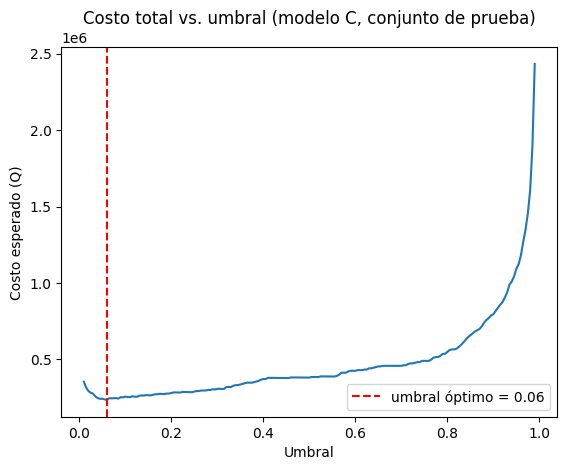

In [10]:
COSTO_FRAUDE_NO_DETECTADO = 4200
COSTO_BLOQUEO_LEGITIMO = 180

mejor_umbral, detalle_costos = analisis_costo(y_seq_test, scores_C_test,
                                               costo_fraude_no_detectado=COSTO_FRAUDE_NO_DETECTADO,
                                               costo_bloqueo_legitimo=COSTO_BLOQUEO_LEGITIMO)
print('Umbral óptimo:', mejor_umbral)

costos = [r['costo'] for r in detalle_costos]
umbrales = [r['umbral'] for r in detalle_costos]
plt.plot(umbrales, costos)
plt.axvline(mejor_umbral, color='red', linestyle='--', label=f'umbral óptimo = {mejor_umbral:.2f}')
plt.xlabel('Umbral')
plt.ylabel('Costo esperado (Q)')
plt.title('Costo total vs. umbral (modelo C, conjunto de prueba)')
plt.legend()
plt.show()

In [11]:
# Comparación del costo en el umbral óptimo contra dos referencias:
# - "sin modelo": nadie se bloquea, todos los fraudes pasan.
# - "umbral por defecto" (0.5): el que se usó en las secciones anteriores.
detalle_optimo = min(detalle_costos, key=lambda r: r['costo'])
detalle_por_defecto = min(detalle_costos, key=lambda r: abs(r['umbral'] - 0.5))

n_fraudes_test = int(y_seq_test.sum())
costo_sin_modelo = n_fraudes_test * COSTO_FRAUDE_NO_DETECTADO

dias_test = (test_ev['trans_date_trans_time'].max() - test_ev['trans_date_trans_time'].min()).days
meses_test = dias_test / 30

ahorro_vs_sin_modelo = costo_sin_modelo - detalle_optimo['costo']
ahorro_vs_default = detalle_por_defecto['costo'] - detalle_optimo['costo']

print(f"Duración del conjunto de prueba: {dias_test} días (~{meses_test:.1f} meses)")
print(f"Costo sin ningún modelo (dejar pasar todo): Q{costo_sin_modelo:,.0f}")
print(f"Costo con umbral por defecto (0.5): Q{detalle_por_defecto['costo']:,.0f}"
      f" ({detalle_por_defecto['fraudes_no_detectados']} fraudes no detectados,"
      f" {detalle_por_defecto['bloqueos_legitimos']} bloqueos legítimos)")
print(f"Costo con umbral óptimo ({detalle_optimo['umbral']:.2f}): Q{detalle_optimo['costo']:,.0f}"
      f" ({detalle_optimo['fraudes_no_detectados']} fraudes no detectados,"
      f" {detalle_optimo['bloqueos_legitimos']} bloqueos legítimos)")
print(f"Ahorro del umbral óptimo frente a no tener modelo: Q{ahorro_vs_sin_modelo:,.0f} en el período"
      f" (~Q{ahorro_vs_sin_modelo / meses_test:,.0f} por mes)")
print(f"Ahorro del umbral óptimo frente al umbral por defecto (0.5): Q{ahorro_vs_default:,.0f} en el período"
      f" (~Q{ahorro_vs_default / meses_test:,.0f} por mes)")

Duración del conjunto de prueba: 107 días (~3.6 meses)
Costo sin ningún modelo (dejar pasar todo): Q6,459,600
Costo con umbral por defecto (0.5): Q381,360 (89 fraudes no detectados, 42 bloqueos legítimos)
Costo con umbral óptimo (0.06): Q235,620 (39 fraudes no detectados, 399 bloqueos legítimos)
Ahorro del umbral óptimo frente a no tener modelo: Q6,223,980 en el período (~Q1,745,041 por mes)
Ahorro del umbral óptimo frente al umbral por defecto (0.5): Q145,740 en el período (~Q40,862 por mes)


Con el umbral por defecto de 0.5, el modelo C deja pasar 89 fraudes y bloquea 42 transacciones legítimas en los 3.6 meses del conjunto de prueba, con un costo de Q381,360. El umbral que minimiza el costo total es más bajo, 0.06: con ese umbral solo se escapan 39 fraudes, aunque se bloquean 399 transacciones legítimas, y el costo baja a Q235,620. Esto ocurre porque un fraude no detectado cuesta 23 veces más que bloquear por error una transacción legítima (Q4,200 contra Q180), así que conviene marcar como riesgosas más transacciones aunque la mayoría de esas alertas resulten ser falsas alarmas.

Frente a no tener ningún modelo (dejar pasar todas las transacciones), operar en el umbral óptimo con el modelo C ahorra alrededor de Q6,223,980 en el período, es decir, cerca de Q1,745,000 por mes. Incluso comparado contra usar el mismo modelo C con el umbral por defecto de 0.5, bajar el umbral al valor óptimo ahorra Q145,740 adicionales en el período, cerca de Q40,900 por mes. La decisión de umbral importa tanto como la elección del modelo: un mismo modelo, mal calibrado, deja dinero sobre la mesa.

## 6. Recomendación y límites

Antes de dar la recomendación final se revisa en qué tipo de comercio el modelo C (el candidato final), ya con el umbral óptimo de la sección anterior, sigue sin detectar fraudes. Esto ayuda a identificar un patrón de error concreto en lugar de quedarse solo con el número global de exhaustividad.

In [12]:
# Análisis de error: exhaustividad del modelo C (candidato final) por categoría
# de comercio, usando el umbral óptimo encontrado en la sección anterior.
predicciones_test = pd.DataFrame({
    'trans_num': ids_test,
    'es_fraude': y_seq_test,
    'score': scores_C_test,
})
predicciones_test['prediccion'] = (predicciones_test['score'] >= mejor_umbral).astype(int)

info_categoria = test_ev[['trans_num', 'category']].drop_duplicates('trans_num')
predicciones_test = predicciones_test.merge(info_categoria, on='trans_num', how='left')

fraudes_reales = predicciones_test[predicciones_test['es_fraude'] == 1]
resumen_por_categoria = fraudes_reales.groupby('category').agg(
    n_fraudes=('es_fraude', 'size'),
    fraudes_detectados=('prediccion', 'sum'),
)
resumen_por_categoria['exhaustividad'] = (
    resumen_por_categoria['fraudes_detectados'] / resumen_por_categoria['n_fraudes']
)
resumen_por_categoria = resumen_por_categoria.sort_values('exhaustividad')

print(resumen_por_categoria)

                n_fraudes  fraudes_detectados  exhaustividad
category                                                    
travel                 18                  16       0.888889
grocery_net            24                  22       0.916667
misc_pos               57                  53       0.929825
shopping_pos          182                 174       0.956044
personal_care          49                  47       0.959184
misc_net              178                 172       0.966292
health_fitness         30                  29       0.966667
food_dining            32                  31       0.968750
shopping_net          343                 334       0.973761
kids_pets              48                  47       0.979167
entertainment          49                  48       0.979592
gas_transport         125                 123       0.984000
grocery_pos           356                 356       1.000000
home                   47                  47       1.000000


Con el umbral óptimo, el modelo C ya detecta el 100 por ciento de los fraudes en grocery_pos y home, y más del 96 por ciento en food_dining, health_fitness, misc_net y shopping_net. El patrón de error concreto está en el otro extremo: en travel detecta solo el 89 por ciento de los fraudes, en grocery_net el 92 por ciento y en misc_pos el 93 por ciento. Travel y grocery_net son categorías con pocas transacciones en el conjunto de prueba (18 y 24 fraudes respectivamente), así que el modelo tiene menos ejemplos de los que aprender ese patrón particular; es un límite real y no solo ruido, porque el mismo patrón (peor desempeño en categorías poco frecuentes) es consistente con cómo se entrenó el modelo.

Con toda esta evidencia, la recomendación es reemplazar el sistema actual basado únicamente en variables agregadas por el modelo secuencial con embedding de categoría (modelo C). El orden de las transacciones sí aporta información que los agregados no capturan (la permutación controlada lo confirma), esa información se traduce en más fraude detectado (exhaustividad de 0.94 contra 0.60 del modelo A) y, calibrando el umbral con el costo real del negocio, el ahorro esperado es de alrededor de Q1.75 millones al mes frente a no tener modelo.

Esta recomendación cambiaría bajo tres condiciones. Primero, si en producción aparece un tipo de fraude que dependa principalmente de variables temporales que no se ven en entrenamiento, porque la prueba de retirar variables temporales mostró que buena parte del desempeño del modelo secuencial depende de esa información y no solo del orden puro. Segundo, si el costo relativo entre fraude no detectado y bloqueo legítimo cambia de forma importante, porque el umbral óptimo se movería y valdría la pena recalcularlo. Tercero, si la tasa de fraude o el comportamiento de compra cambia de forma sostenida respecto a los datos de entrenamiento (2019 a 2020), o si aparecen categorías de comercio nuevas que el embedding nunca vio, habría que reentrenar y volver a validar antes de confiar en el modelo, ya que no hay garantía de que el patrón aprendido siga siendo válido bajo un cambio de conducta de los clientes o de los tipos de fraude.

## 7. Guardar artefactos

Se guardan los pesos del modelo A (línea base), del modelo B (secuencial, requerido por el núcleo común) y del modelo C (con embedding de categoría, el candidato final recomendado), junto con los parámetros de preparación necesarios para reproducir los puntajes: el diccionario de categorías, el largo de secuencia, las columnas usadas y el umbral operativo elegido en la sección de decisión económica, ya calculado sobre el modelo C.

In [13]:
import os
import torch
import joblib
import json

os.makedirs('artefactos', exist_ok=True)

joblib.dump(modelo_A, 'artefactos/modelo_A.pkl')
joblib.dump(scaler_A, 'artefactos/scaler_A.pkl')
torch.save(modelo_B.state_dict(), 'artefactos/modelo_B.pt')
torch.save(modelo_C.state_dict(), 'artefactos/modelo_C.pt')

with open('artefactos/preproc_params.json', 'w') as f:
    json.dump({
        'modelo_recomendado': 'C',
        'cat2cod': cat2cod,
        'longitud_secuencia': LONGITUD_SECUENCIA,
        'columnas_agregadas': COLUMNAS_AGREGADAS,
        'columnas_evento': ['amt', 'category_cod', 'hora_del_dia', 'dias_desde_ultima_tx'],
        'n_categorias': N_CATEGORIAS,
        'umbral_operativo': mejor_umbral,
        'costo_fraude_no_detectado': COSTO_FRAUDE_NO_DETECTADO,
        'costo_bloqueo_legitimo': COSTO_BLOQUEO_LEGITIMO,
    }, f, indent=2, ensure_ascii=False)

print('Artefactos guardados en artefactos/')

Artefactos guardados en artefactos/
